In [42]:
import pandas as pd
from pprint import pprint
#filter to only the rows where the model is resnet50
# gb = cc.groupby(["backbone", "pooling", "sampler", "weight_config", "fulltune"])
coralcam_groups = ['aggression', 'biting']
fishfollow_groups = ['habitat', 'movement', 'bites', 'social_interaction', 'not_visible']

cc = pd.concat([pd.read_csv("../results/eccv/coralcam_eccv_label_tolerance_7.csv"), 
                pd.read_csv("../results/new_grouping/coralcam_results_label_tolerance_7.csv")], ignore_index=True)

ff = pd.concat([pd.read_csv("../results/eccv/fishfollow_eccv_label_tolerance_7.csv"), 
                pd.read_csv("../results/new_grouping/fishfollow_results_label_tolerance_7.csv")], ignore_index=True)

In [43]:
# Load YAML
import yaml

with open("flops.yaml", "r") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
flops = pd.DataFrame(data)

In [44]:
merged = pd.merge(cc, flops[['id', 'flops']], on="id", how="inner")
print(merged.columns)
merged[['backbone','pooling', 'f1_macro', 'flops']]

Index(['id', 'model', 'epochs', 'dataset', 'monitor', 'pooling', 'sampler',
       'shuffle', 'backbone', 'fulltune', 'optimizer', 'batch_size',
       'classifier', 'label_type', 'val_subset', 'train_subset',
       'weight_decay', 'learning_rate', 'sliding_style', 'weight_config',
       'freeze_backbone', 'training_entity', 'training_run_id',
       'training_project', 'test_sliding_style', 'max_samples_per_class',
       'run_id', 'f1_micro', 'f1_macro', 'precision_micro', 'precision_macro',
       'recall_micro', 'recall_macro', 'acc', 'mAP', 'f1_per_class',
       'precision_per_class', 'recall_per_class', 'positive_per_class',
       'ap_per_class', 'confusion_matrix', 'biting_f1_micro',
       'biting_f1_macro', 'biting_precision_micro', 'biting_precision_macro',
       'biting_recall_micro', 'biting_recall_macro', 'biting_acc',
       'biting_mAP', 'aggression_f1_micro', 'aggression_f1_macro',
       'aggression_precision_micro', 'aggression_precision_macro',
       'aggressio

,backbone,pooling,f1_macro,flops
0,dinov3_base,attention,0.309183,17446400256
1,dinov3_base,attention,0.288791,17446400256
2,dinov3_base,mean,0.025878,17207030784
3,dinov3_base,mean,0.241447,17207030784
4,videomae_large,attention,0.260826,479681774848
5,videomae_large,attention,0.450383,479681774848
6,videomae_large,mean,0.243682,476380103936
7,videomae_large,mean,0.230205,476380103936
8,dinov3_large,mean,0.237616,60904864000
9,dinov3_large,mean,0.230111,60904864000


In [45]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_flops(df, pooling_type=None):
    plt.figure()

    # Optional filtering
    if pooling_type is not None:
        df = df[df["pooling"] == pooling_type]

    backbones = df["backbone"].unique()
    colors = plt.cm.tab10(range(len(backbones)))

    marker_map = {
        "attention": "o",
        "mean": "s"
    }

    # Plot points
    for backbone, color in zip(backbones, colors):
        for pooling, marker in marker_map.items():
            if pooling_type is not None and pooling != pooling_type:
                continue

            subset = df[
                (df["backbone"] == backbone) &
                (df["pooling"] == pooling)
            ]

            if not subset.empty:
                plt.scatter(
                    subset["flops"],
                    subset["f1_macro"],
                    color=color,
                    marker=marker
                )

    plt.xscale("log")
    plt.xlabel("FLOPs (log scale)")
    plt.ylabel("F1 Macro")
    plt.title("Performance vs Compute")

    # -------- Backbone legend --------
    color_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=8,
               label=backbone)
        for backbone, color in zip(backbones, colors)
    ]

    legend1 = plt.legend(handles=color_handles, title="Backbone", loc="upper left")
    plt.gca().add_artist(legend1)

    # -------- Pooling legend (only if plotting all) --------
    if pooling_type is None:
        marker_handles = [
            Line2D([0], [0], marker=marker, color='black',
                   linestyle='None', markersize=8,
                   label=pooling)
            for pooling, marker in marker_map.items()
        ]
        plt.legend(handles=marker_handles, title="Pooling", loc="lower right")

    plt.show()

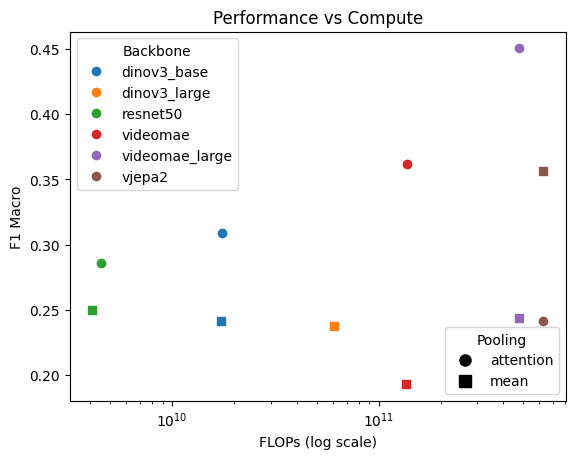

In [46]:
plot_flops(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "flops": "first"   # or "max" if flops varies slightly
        }).reset_index())

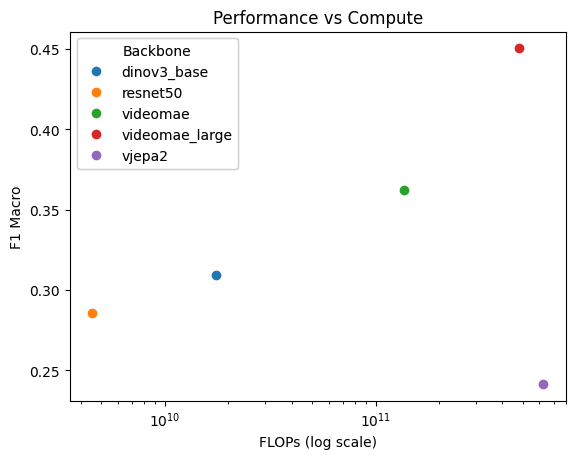

In [47]:
plot_flops(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "flops": "first"   # or "max" if flops varies slightly
        }).reset_index(), pooling_type="attention")

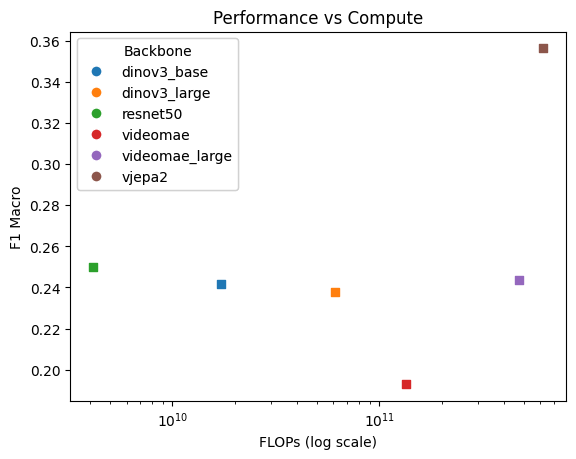

In [48]:
plot_flops(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "flops": "first"   # or "max" if flops varies slightly
        }).reset_index(), pooling_type="mean")

In [49]:
with open("parameters.yaml", "r") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
parameters = pd.DataFrame(data)
merged = pd.merge(cc, parameters[['id', 'parameters']], on="id", how="inner")


In [50]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_params(df, pooling_type=None):
    plt.figure()

    # Optional filtering
    if pooling_type is not None:
        df = df[df["pooling"] == pooling_type]

    backbones = df["backbone"].unique()
    colors = plt.cm.tab10(range(len(backbones)))

    marker_map = {
        "attention": "o",
        "mean": "s"
    }

    # Plot points
    for backbone, color in zip(backbones, colors):
        for pooling, marker in marker_map.items():
            if pooling_type is not None and pooling != pooling_type:
                continue

            subset = df[
                (df["backbone"] == backbone) &
                (df["pooling"] == pooling)
            ]

            if not subset.empty:
                plt.scatter(
                    subset["parameters"],
                    subset["f1_macro"],
                    color=color,
                    marker=marker
                )

    plt.xscale("log")
    plt.xlabel("Parameters (log scale)")
    plt.ylabel("F1 Macro")
    plt.title("Performance vs Model Size")

    # -------- Backbone legend --------
    color_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=8,
               label=backbone)
        for backbone, color in zip(backbones, colors)
    ]

    legend1 = plt.legend(handles=color_handles, title="Backbone", loc="upper left")
    plt.gca().add_artist(legend1)

    # -------- Pooling legend (only if plotting all) --------
    if pooling_type is None:
        marker_handles = [
            Line2D([0], [0], marker=marker, color='black',
                   linestyle='None', markersize=8,
                   label=pooling)
            for pooling, marker in marker_map.items()
        ]
        plt.legend(handles=marker_handles, title="Pooling", loc="lower right")

    plt.show()

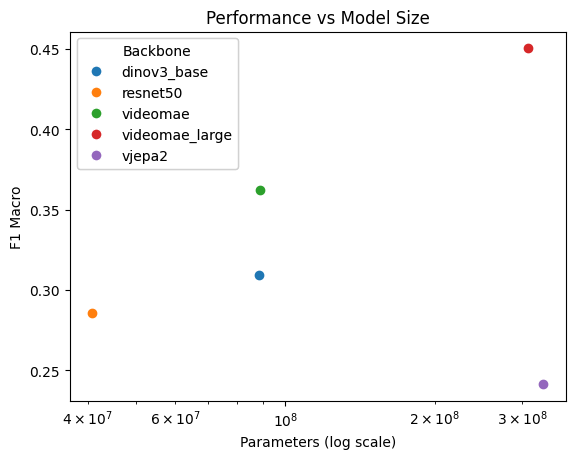

In [51]:
plot_params(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "parameters": "first"   # or "max" if params varies slightly
        }).reset_index(), pooling_type="attention")


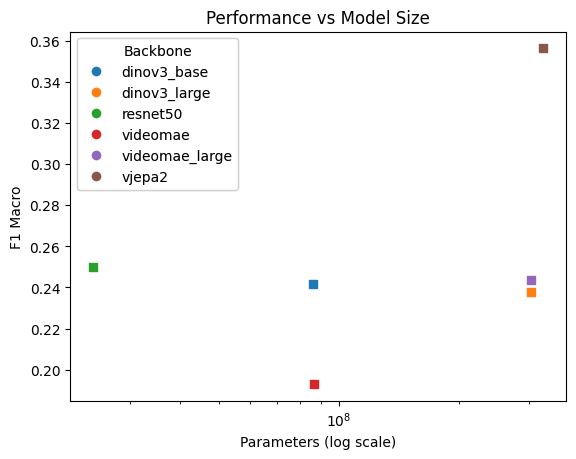

In [52]:
plot_params(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "parameters": "first"   # or "max" if params varies slightly
        }).reset_index(), pooling_type="mean")